# Лабораторная работа №4. Анализ ФПГ-сигнала

Егорова Варвара, 408575

Ташкинова Татьяна, 413084

Аббясов Радислам, 367038

## Импорты

In [ ]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 14.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import neurokit2 as nk

plt.rcParams["figure.figsize"] = (15, 4)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving calm_FPG.dat to calm_FPG.dat
Saving walk_FPG.dat to walk_FPG.dat
Saving after_run1_FPG.dat to after_run1_FPG.dat
Saving after_run5_FPG.dat to after_run5_FPG.dat
Saving run5_FPG.dat to run5_FPG.dat
Saving run1_FPG.dat to run1_FPG.dat
Saving after_walk_FPG.dat to after_walk_FPG.dat


In [ ]:
files = list(uploaded.keys())

print("Загруженные файлы:")
for f in files:
    print(f)

Загруженные файлы:
calm_FPG.dat
walk_FPG.dat
after_run1_FPG.dat
after_run5_FPG.dat
run5_FPG.dat
run1_FPG.dat
after_walk_FPG.dat


In [ ]:
def load_signal(filename):

    with open(filename, "r") as f:
        text = f.read()

    text = text.replace("\n", " ").replace(",", " ")

    values = np.array([float(v) for v in text.split()])

    # защита от битых файлов
    if len(values) % 2 != 0:
        values = values[:-1]

    values = values.reshape(-1, 2)

    time = values[:, 0]
    signal = values[:, 1]

    return time, signal

In [ ]:
signals = {}
fs = None

for file in files:

    time, signal = load_signal(file)

    signals[file] = {
        "time": time,
        "signal": signal,
        "duration": time[-1] - time[0]
    }

    if fs is None:
      time_diff = np.diff(time)
      avg_interval = np.mean(time_diff)
      fs = int(round(1 / avg_interval))
      print(f"Частота выборки: {fs} Hz")

    print(f"\nФайл: {file}")

    print("Размер сигнала:", len(signal))

    print("Первые значения сигнала:")
    print(signal[:10])

    print(f"Продолжительность: {signals[file]["duration"]}")

    print("Минимум:", np.min(signal))
    print("Максимум:", np.max(signal))

Частота выборки: 319 Hz

Файл: calm_FPG.dat
Размер сигнала: 96747
Первые значения сигнала:
[2.58823538 2.58823538 2.58823538 2.58823538 2.58823538 2.58823538
 2.58823538 2.58823538 2.58823538 2.58823538]
Продолжительность: 303.37514018999997
Минимум: 2.49019599
Максимум: 2.60784316

Файл: walk_FPG.dat
Размер сигнала: 95783
Первые значения сигнала:
[2.54901958 2.54901958 2.54901958 2.54901958 2.56862736 2.56862736
 2.56862736 2.56862736 2.56862736 2.56862736]
Продолжительность: 300.37255860000005
Минимум: 2.41176462
Максимум: 3.78431368

Файл: after_run1_FPG.dat
Размер сигнала: 38650
Первые значения сигнала:
[2.56862736 2.56862736 2.56862736 2.56862736 2.56862736 2.56862736
 2.56862736 2.56862736 2.56862736 2.56862736]
Продолжительность: 121.19030760999999
Минимум: 2.43137264
Максимум: 2.62745094

Файл: after_run5_FPG.dat
Размер сигнала: 52635
Первые значения сигнала:
[2.66666675 2.66666675 2.64705873 2.64705873 2.64705873 2.64705873
 2.64705873 2.64705873 2.64705873 2.64705873]
Продолж

## Аналитические функции

In [ ]:
def detect_peaks(signal, fs, min_distance_s=0.2, prominence_factor=0.4):
    distance = int(fs * min_distance_s)

    median_val = np.median(signal)
    mad = np.median(np.abs(signal - median_val))
    robust_std = 1.4826 * mad

    prominence = robust_std * prominence_factor

    peak_idx, _ = find_peaks(
        signal,
        distance=distance,
        prominence=prominence
    )

    peak_time = peak_idx / fs

    return peak_idx, peak_time

In [ ]:
def calculate_heart_rate(peak_times, min_rr_ms=400, max_rr_ms=1200):
    if peak_times is None or len(peak_times) < 2:
        return np.array([]), np.array([])

    rr_intervals_sec = np.diff(peak_times)
    rr_intervals_ms = rr_intervals_sec * 1000.0

    valid_intervals = (rr_intervals_ms >= min_rr_ms) & (rr_intervals_ms <= max_rr_ms)
    filtered_rr = rr_intervals_ms[valid_intervals]

    hr_values = 60000.0 / filtered_rr

    return filtered_rr, hr_values

In [ ]:
def calculate_hrv_metrics(rr_intervals_ms):
    if rr_intervals_ms is None or len(rr_intervals_ms) < 2:
        return {}

    rr = np.asarray(rr_intervals_ms)

    avg_rr = np.mean(rr)
    avg_hr = 60000.0 / avg_rr
    sdnn_value = np.std(rr)

    rr_diffs = np.diff(rr)
    rmssd_value = np.sqrt(np.mean(rr_diffs ** 2))

    nn50_count = np.sum(np.abs(rr_diffs) > 50)
    pnn50_value = (nn50_count / len(rr_diffs)) * 100

    variation_coeff = sdnn_value / avg_rr

    rr_min_val = np.min(rr)
    rr_max_val = np.max(rr)
    rr_span = rr_max_val - rr_min_val

    return {
        "mean_hr_bpm": round(avg_hr, 1),
        "mean_rr_ms": round(avg_rr, 1),
        "sdnn_ms": round(sdnn_value, 1),
        "rmssd_ms": round(rmssd_value, 1),
        "pnn50_percent": round(pnn50_value, 1),
        "cv": round(variation_coeff, 3),
        "min_rr_ms": round(rr_min_val, 1),
        "max_rr_ms": round(rr_max_val, 1),
        "rr_range_ms": round(rr_span, 1),
        "n_intervals": int(len(rr))
    }

## Вспомогательные функции

In [ ]:
def crop_signal(signal, fs, trim_start_sec=10, trim_end_sec=10):
    start = int(trim_start_sec * fs)
    stop = int(len(signal) - trim_end_sec * fs)
    return signal[start:stop]


def highpass_filter(signal, fs, cutoff_hz=0.2, filter_order=2):
    if len(signal) < 20:
        return signal

    nyquist = fs / 2
    b, a = butter(filter_order, cutoff_hz/ nyquist, btype='highpass')

    padlen = min(3 * (max(len(b), len(a)) - 1), len(signal) - 1)
    return filtfilt(b, a, signal, padlen=padlen)


def lowpass_filter(signal, fs, cutoff_hz=12, filter_order=4):
    if len(signal) < 20:
        return signal

    nyq = fs * 0.5
    normalized_cutoff = cutoff_hz / nyq

    b, a = butter(filter_order, normalized_cutoff, btype="lowpass")
    return filtfilt(b, a, signal)

In [ ]:
def plot_signal(signal, fs, title="Signal"):
    signal = np.asarray(signal)

    total_time = len(signal) / fs
    time = np.linspace(0, total_time, len(signal), endpoint=False)

    plt.figure(figsize=(15, 5))
    plt.plot(time, signal, linewidth=1.0)

    plt.title(f"{title} (duration: {total_time:.1f} s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    stats = {
        "min": signal.min(),
        "max": signal.max(),
        "mean": signal.mean(),
        "std": signal.std()
    }

    print(f"\n{title} stats:")
    print(f"duration: {total_time:.1f} s")
    print(f"min: {stats['min']:.4f}")
    print(f"max: {stats['max']:.4f}")
    print(f"mean: {stats['mean']:.4f}")
    print(f"std: {stats['std']:.4f}")

In [ ]:
def plot_highpass_sliding_analysis(signal, fs,
                                  start_trim_sec=50,
                                  end_trim_sec=20,
                                  cutoff_hz=0.5,
                                  filter_orders=(2, 4, 6),
                                  window_sec=30,
                                  title="Signal"):

    cropped = crop_signal(signal, fs, start_trim_sec, end_trim_sec)

    window_len = int(window_sec * fs)
    step_len = int(window_len / 2)

    centers = []
    std_by_order = {o: [] for o in filter_orders}

    n_windows = len(cropped) - window_len

    for i in range(0, n_windows, step_len):
        segment = cropped[i:i + window_len]

        center_time = (i + window_len / 2) / fs
        centers.append(center_time)

        for order in filter_orders:
            filtered = highpass_filter(segment, fs, cutoff_hz=cutoff_hz, filter_order=order)
            std_by_order[order].append(np.std(filtered))

    plt.figure(figsize=(15, 6))

    palette = ['blue', 'red', 'green', 'orange', 'purple']

    for idx, order in enumerate(filter_orders):
        plt.plot(
            centers,
            std_by_order[order],
            linewidth=1.5,
            color=palette[idx % len(palette)],
            label=f"order {order}"
        )

    plt.title(
        f"High-pass filtering comparison (cutoff {cutoff_hz} Hz) - {title}\n"
        f"Windowed STD over {window_sec}s segments"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("STD of signal")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nMean STD values for {title}:")

    for order in filter_orders:
        mean_val = np.mean(std_by_order[order])
        print(f"  order {order}: {mean_val:.4f}")

In [ ]:
def plot_lowpass_sliding_analysis(signal, fs,
                                 cutoff_hz=8,
                                 filter_orders=(2, 4, 6),
                                 window_sec=30,
                                 title="Signal"):

    window_len = int(window_sec * fs)
    step_len = int(window_len / 2)

    centers = []
    std_values = {o: [] for o in filter_orders}

    max_start = len(signal) - window_len

    for start in range(0, max_start, step_len):
        segment = signal[start:start + window_len]

        center_time = (start + window_len / 2) / fs
        centers.append(center_time)

        for order in filter_orders:
            filtered_segment = lowpass_filter(segment, fs, cutoff_hz=cutoff_hz, filter_order=order)
            std_values[order].append(np.std(filtered_segment))

    plt.figure(figsize=(15, 6))

    palette = ['blue', 'red', 'green', 'orange', 'purple']

    for i, order in enumerate(filter_orders):
        plt.plot(
            centers,
            std_values[order],
            linewidth=1.5,
            color=palette[i % len(palette)],
            label=f"order {order}"
        )

    plt.title(f"Low-pass filter comparison (cutoff {cutoff_hz} Hz) - {title}")
    plt.xlabel("Time (s)")
    plt.ylabel("STD")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n{title} summary:")
    for order in filter_orders:
        print(f"  order {order}: {np.mean(std_values[order]):.4f}")

In [ ]:
def plot_peaks_first_10s(signal, peak_indices, fs, title="Signal"):
    duration_samples = int(10 * fs)

    segment = signal[:duration_samples]
    time = np.arange(duration_samples) / fs

    valid_peaks = peak_indices[peak_indices < duration_samples]

    plt.figure(figsize=(15, 4))
    plt.plot(time, segment, linewidth=0.8, label="Signal")

    plt.scatter(
        valid_peaks / fs,
        signal[valid_peaks],
        color="red",
        s=30,
        zorder=5,
        label=f"Peaks ({len(valid_peaks)})"
    )

    plt.title(f"{title} — Peak detection (first 10 s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_hrv_analysis(rr_intervals, hr_values, title="HRV Analysis"):
    rr = np.asarray(rr_intervals)
    hr = np.asarray(hr_values)

    fig, ax = plt.subplots(2, 2, figsize=(14, 8))

    mean_rr = rr.mean()
    mean_hr = hr.mean()

    ax[0, 0].plot(rr, marker='o', linewidth=0.8, markersize=3)
    ax[0, 0].axhline(mean_rr, linestyle='--',
                     label=f"mean {mean_rr:.1f} ms")
    ax[0, 0].set_title("RR intervals")
    ax[0, 0].set_xlabel("Beat index")
    ax[0, 0].set_ylabel("RR (ms)")
    ax[0, 0].grid(alpha=0.3)
    ax[0, 0].legend()

    ax[0, 1].plot(hr, marker='o', linewidth=0.8, markersize=3)
    ax[0, 1].axhline(mean_hr, linestyle='--',
                     label=f"mean {mean_hr:.1f} bpm")
    ax[0, 1].set_title("Heart rate")
    ax[0, 1].set_xlabel("Beat index")
    ax[0, 1].set_ylabel("BPM")
    ax[0, 1].grid(alpha=0.3)
    ax[0, 1].legend()

    ax[1, 0].hist(rr, bins=np.arange(np.min(rr_intervals), np.max(rr_intervals)+50, 50), color='skyblue', edgecolor='black', alpha=0.7)
    ax[1, 0].axvline(mean_rr, linestyle='--',
                     label=f"mean {mean_rr:.1f} ms")
    ax[1, 0].set_title("RR distribution")
    ax[1, 0].set_xlabel("RR (ms)")
    ax[1, 0].set_ylabel("Count")
    ax[1, 0].grid(alpha=0.3)
    ax[1, 0].legend()

    rr_x = rr[:-1]
    rr_y = rr[1:]

    ax[1, 1].scatter(rr_x, rr_y, s=15, alpha=0.6)
    ax[1, 1].set_title("Poincaré plot")
    ax[1, 1].set_xlabel("RR(n)")
    ax[1, 1].set_ylabel("RR(n+1)")
    ax[1, 1].grid(alpha=0.3)

    if len(rr) > 1:
        lim_min = min(rr_x.min(), rr_y.min())
        lim_max = max(rr_x.max(), rr_y.max())
        ax[1, 1].plot([lim_min, lim_max], [lim_min, lim_max],
                      linestyle='--', alpha=0.5)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Предобработка

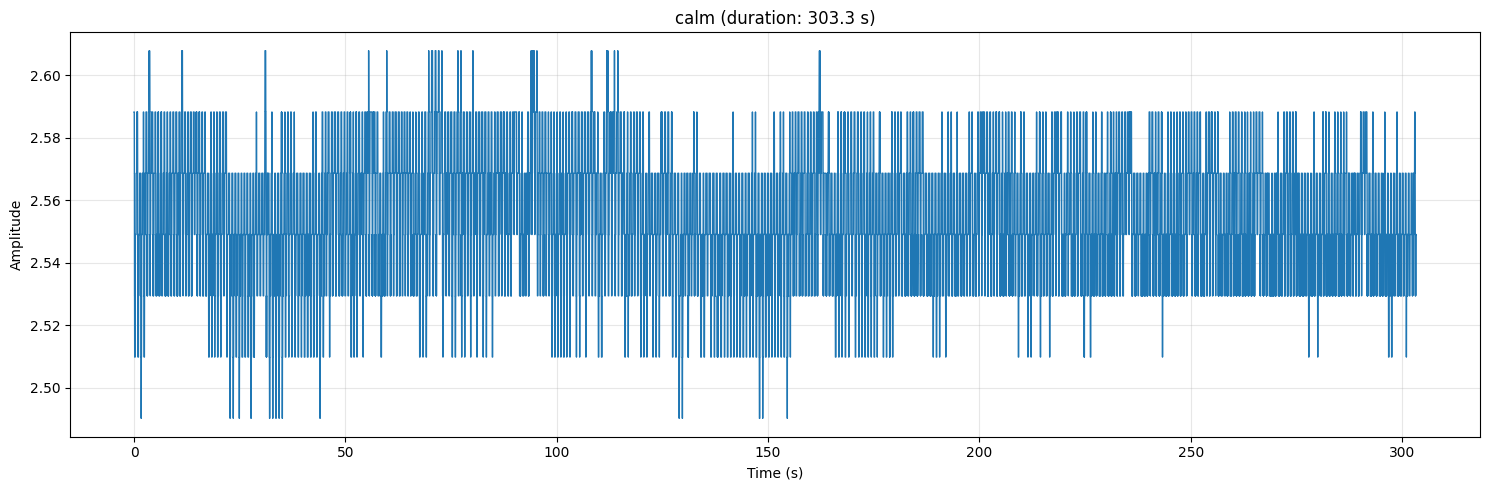


calm stats:
duration: 303.3 s
min: 2.4902
max: 2.6078
mean: 2.5568
std: 0.0207


In [ ]:
plot_signal(signals['calm_FPG.dat']['signal'], fs=fs, title="calm")

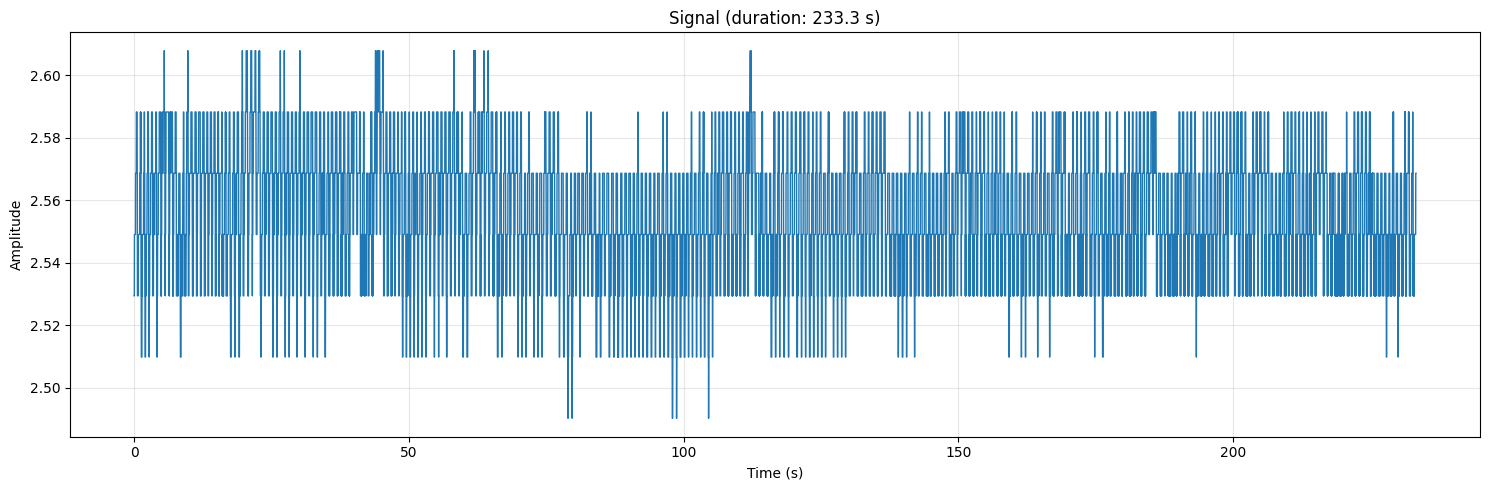


Signal stats:
duration: 233.3 s
min: 2.4902
max: 2.6078
mean: 2.5575
std: 0.0206


In [ ]:
signal1 = crop_signal(signals['calm_FPG.dat']['signal'], fs=fs, trim_start_sec=50, trim_end_sec=20)

plot_signal(signal1, fs=fs)

На этом этапе выполняется подавление медленных изменений сигнала, которые не связаны с сердечной активностью. К ним относятся:

- медленные колебания базовой линии, возникающие из-за дыхания;
- дрейф измерительной системы;
- низкочастотные составляющие, связанные с движениями и артефактами записи.

В сигналах ФПГ основная информативная часть, связанная с сердечными сокращениями, лежит выше примерно 0,5 Гц (что соответствует частоте около 30 ударов в минуту и выше). Поэтому применение высокочастотного фильтра с отсечкой около 0,5 Гц позволяет убрать медленные искажения и стабилизировать базовую линию сигнала, приближая её к нулевому уровню.

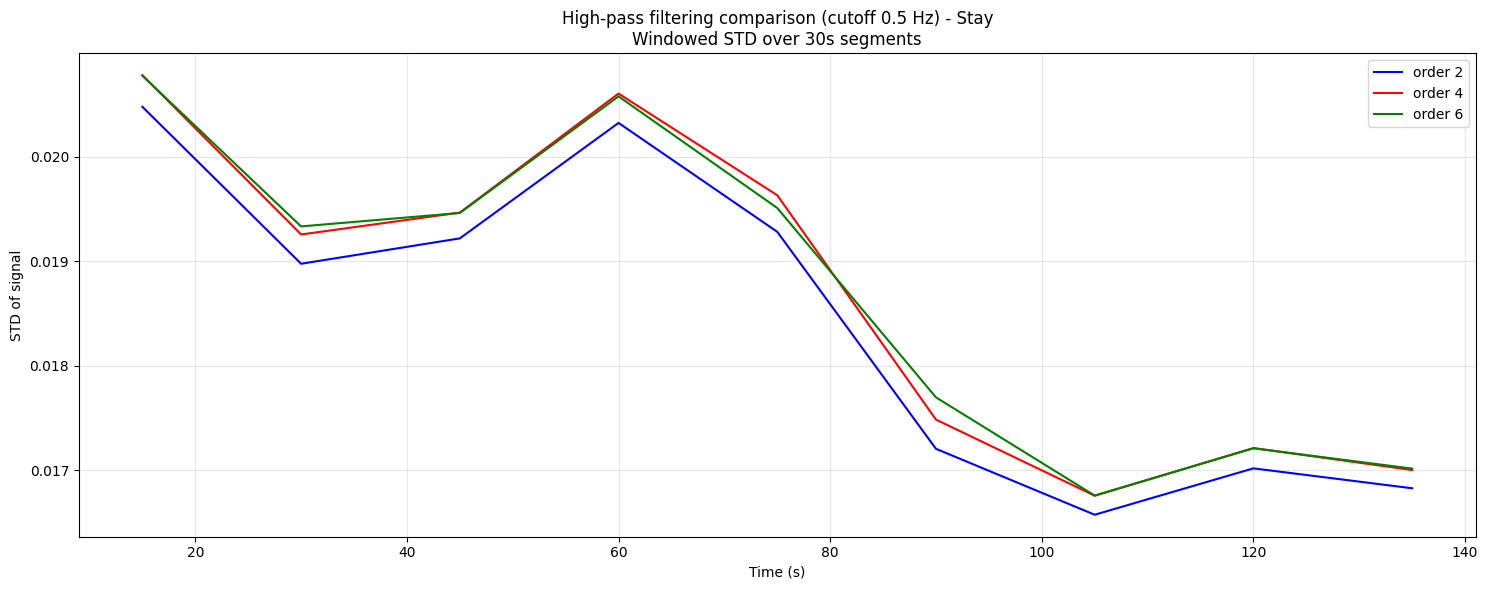


Mean STD values for Stay:
  order 2: 0.0184
  order 4: 0.0187
  order 6: 0.0187


In [ ]:
plot_highpass_sliding_analysis(
    signal=signal1,
    fs=fs,
    start_trim_sec=50,
    end_trim_sec=20,
    filter_orders=[2, 4, 6],
    window_sec=30,
    title="Stay"
)

Три линии практически полностью совпадают, поэтому для снижения вычислительной нагрузки выберем порядок 2

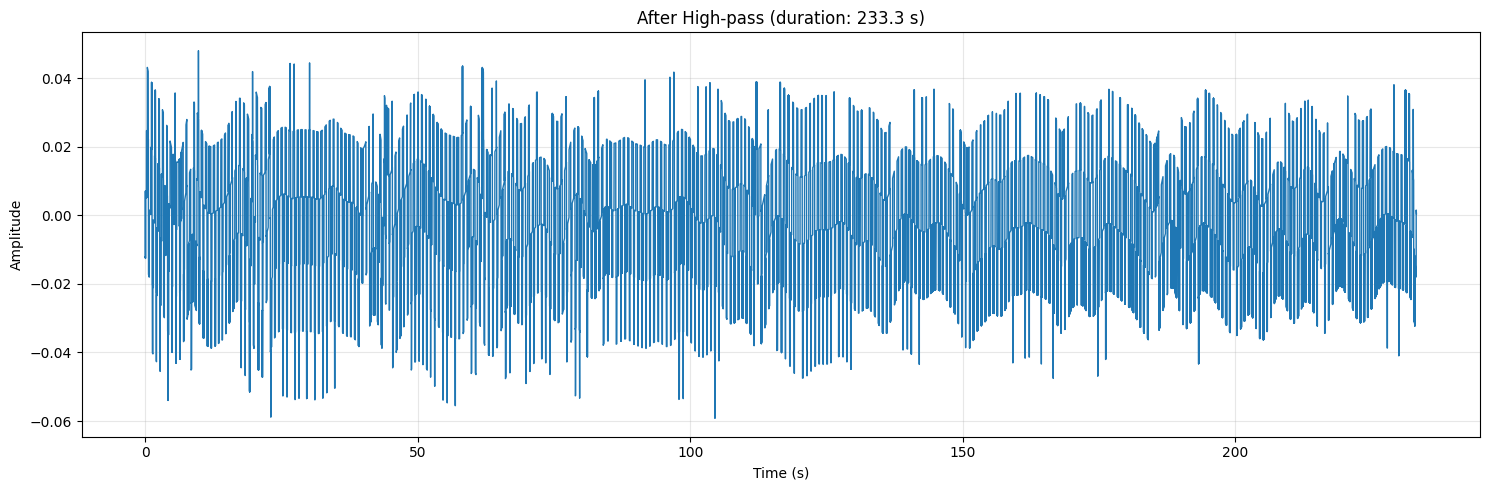


After High-pass stats:
duration: 233.3 s
min: -0.0592
max: 0.0481
mean: 0.0000
std: 0.0192


In [ ]:
signal1_hp = highpass_filter(signal1, fs=fs, filter_order=2)

plot_signal(signal1_hp, fs, title="After High-pass")

На этом этапе из сигнала удаляются высокочастотные помехи, которые не связаны с физиологическими процессами. К ним относятся:

- электромагнитные наводки от сети питания и работающего оборудования;
- микровибрации, возникающие из-за неплотного контакта датчика с кожей;
- случайные импульсные высокочастотные шумы;
- тепловой шум, возникающий в электронных измерительных цепях.

Для сигналов фотоплетизмографии информативная часть, связанная с сердечными сокращениями, обычно сосредоточена ниже примерно 8 Гц. Частоты выше этого порога не несут значимой физиологической информации и в основном представляют собой шумовые компоненты. Поэтому применение низкочастотного фильтра с частотой среза около 8 Гц позволяет эффективно подавить шум и улучшить качество выделения сердечного ритма.

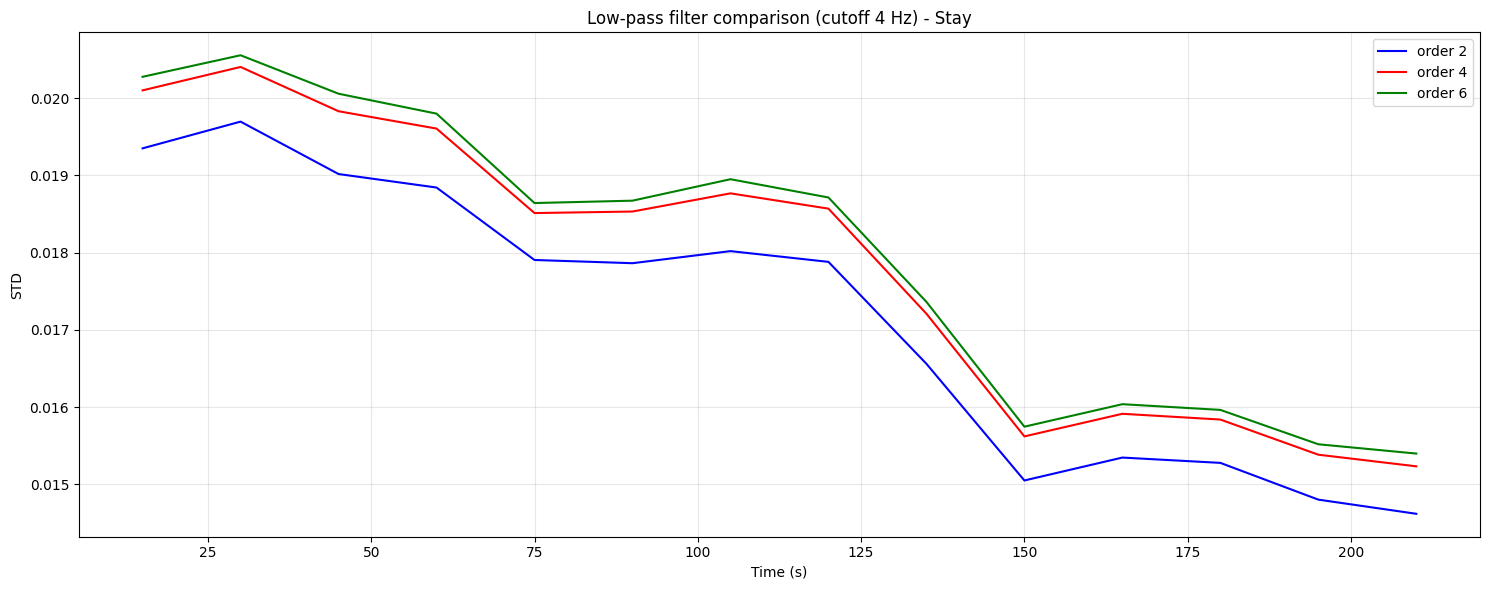


Stay summary:
  order 2: 0.0172
  order 4: 0.0178
  order 6: 0.0180


In [ ]:
plot_lowpass_sliding_analysis(
    signal=signal1_hp,
    fs=fs,
    cutoff_hz=4,
    filter_orders=[2, 4, 6],
    window_sec=30,
    title="Stay"
)

Здесь ситуация аналогичная, как и при низкочастотной фильтрации

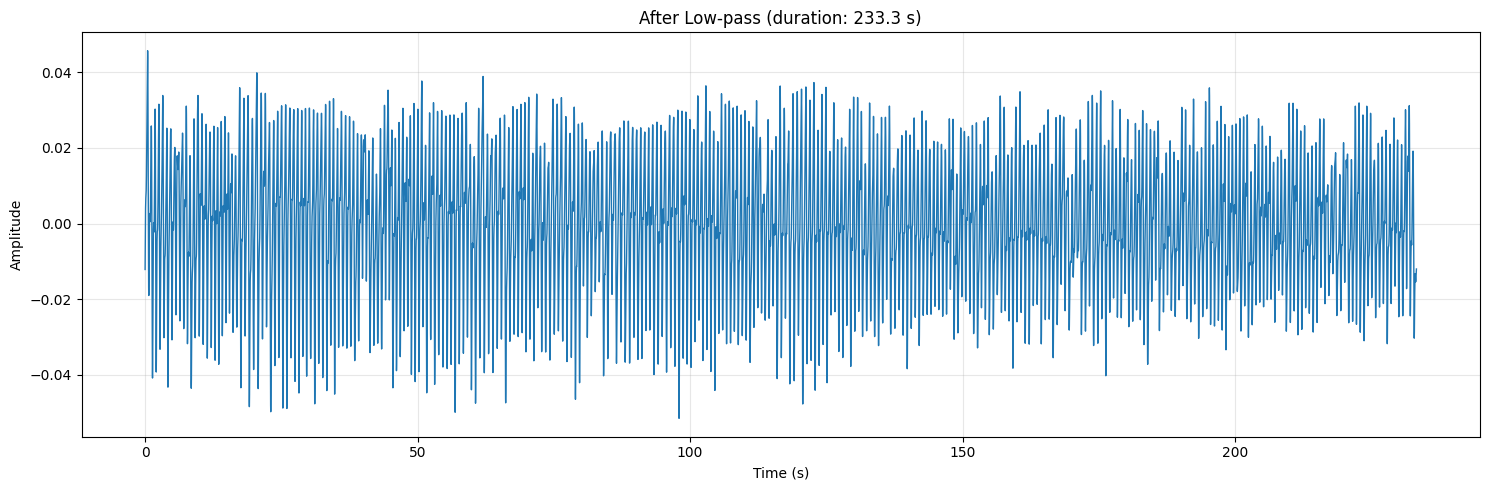


After Low-pass stats:
duration: 233.3 s
min: -0.0515
max: 0.0457
mean: 0.0000
std: 0.0178


In [ ]:
signal1_lp = lowpass_filter(signal1_hp, fs=fs, cutoff_hz=4, filter_order=4)

plot_signal(signal1_lp, fs, title="After Low-pass")

## Анализ

In [ ]:
peaks, peak_times = detect_peaks(signal1_lp, fs,
                                     min_distance_s=0.36,
                                     prominence_factor=0.5)

print(f"Обнаружено пиков: {len(peaks)}")

rr_ms, heart_rate = calculate_heart_rate(peak_times,
                                         min_rr_ms=500,
                                         max_rr_ms=1000)

print(f"Количество RR-интервалов после фильтрации: {len(rr_ms)}")

if len(heart_rate) > 0:
    print(f"Средняя ЧСС: {np.mean(heart_rate):.1f} bpm")
    print(f"Диапазон ЧСС: {np.min(heart_rate):.1f} - {np.max(heart_rate):.1f} bpm")
else:
    print("ЧСС не удалось рассчитать (мало валидных RR-интервалов)")

Обнаружено пиков: 320
Количество RR-интервалов после фильтрации: 319
Средняя ЧСС: 82.6 bpm
Диапазон ЧСС: 72.2 - 94.3 bpm


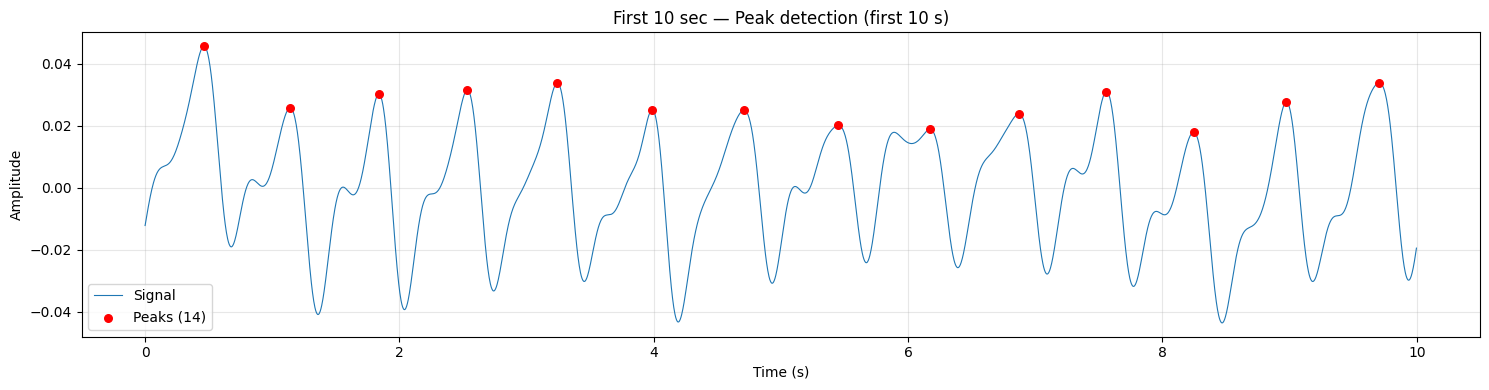

In [ ]:
plot_peaks_first_10s(signal1_lp, peaks, fs=fs, title="First 10 sec")


Основная статистика:
  Обнаружено пиков: 320
  Допустимых RR-интервалов: 319
  Допустимых значений ЧСС: 319

Временные показатели:
  Средняя ЧСС: 82.4 уд/мин
  Средний RR-интервал: 727.9 мс
  SDNN: 35.8 мс
  RMSSD: 34.3 мс
  pNN50: 18.9 %
  CV: 0.049

Диапазонные показатели:
  Диапазон RR: 636.4 - 830.7 мс
  Размах RR: 194.4 мс


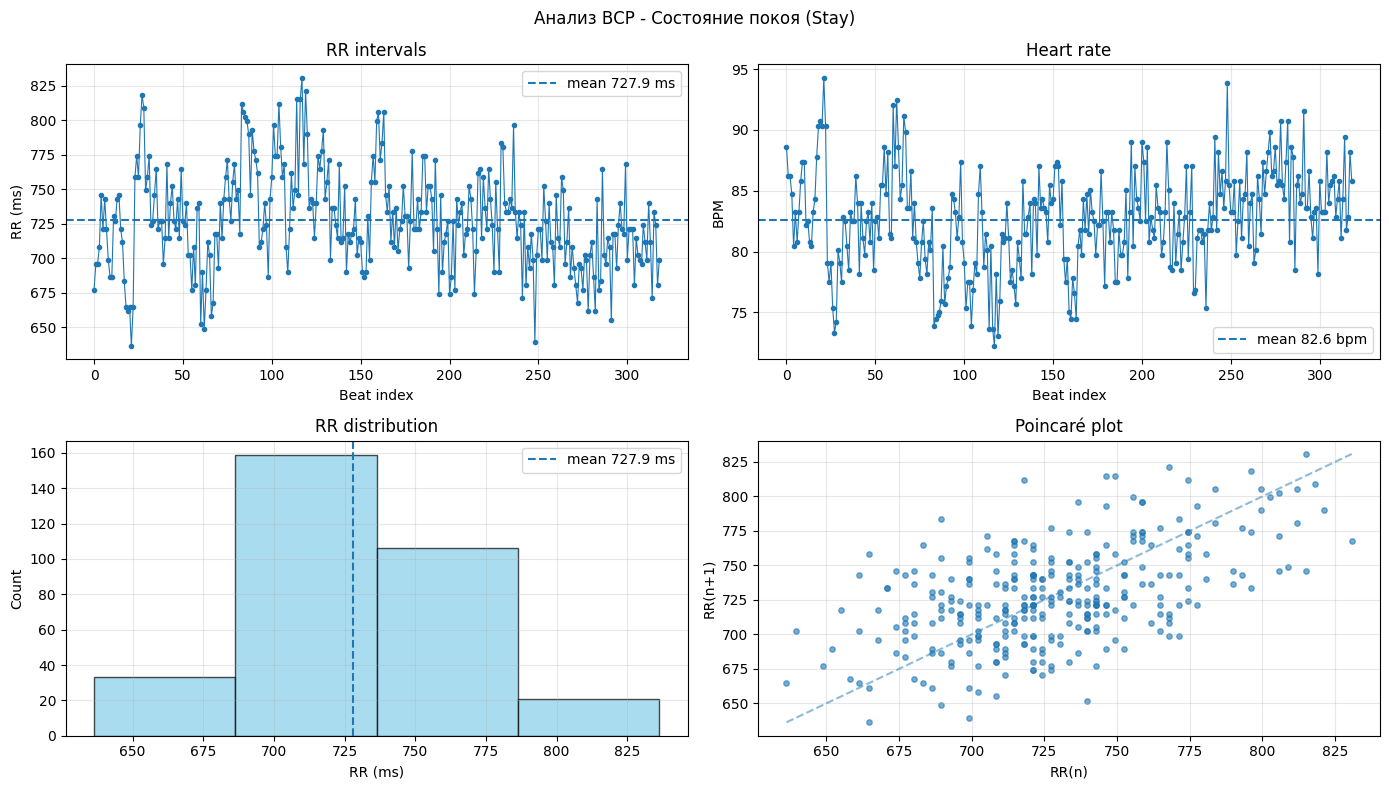

In [ ]:
print(f"\nОсновная статистика:")
print(f"  Обнаружено пиков: {len(peaks)}")
print(f"  Допустимых RR-интервалов: {len(rr_ms)}")
print(f"  Допустимых значений ЧСС: {len(heart_rate)}")

hrv_results = calculate_hrv_metrics(rr_ms)

print(f"\nВременные показатели:")
print(f"  Средняя ЧСС: {hrv_results['mean_hr_bpm']} уд/мин")
print(f"  Средний RR-интервал: {hrv_results['mean_rr_ms']} мс")
print(f"  SDNN: {hrv_results['sdnn_ms']} мс")
print(f"  RMSSD: {hrv_results['rmssd_ms']} мс")
print(f"  pNN50: {hrv_results['pnn50_percent']} %")
print(f"  CV: {hrv_results['cv']}")

print(f"\nДиапазонные показатели:")
print(f"  Диапазон RR: {hrv_results['min_rr_ms']} - {hrv_results['max_rr_ms']} мс")
print(f"  Размах RR: {hrv_results['rr_range_ms']} мс")

plot_hrv_analysis(rr_ms, heart_rate, title="Анализ ВСР - Состояние покоя (Stay)")

In [ ]:
def stress_index(rr_ms):
    rr = np.asarray(rr_ms)

    if len(rr) < 5:
        return np.nan

    mo = np.median(rr)
    mx_dm = np.max(rr) - np.min(rr)

    hist, bin_edges = np.histogram(rr, bins=10)
    amo = np.max(hist) / len(rr) * 100

    if mx_dm == 0 or mo == 0:
        return np.nan

    return amo / (2 * mo * mx_dm)

Анализ: calm
raw: 96747
cropped: 90367
after HP: 90367
after LP: 90367
Индекс напряжения: 0.00003
-0.05702715651066624 0.05227843128483484 0.018484799379246568
Обнаружено пиков: 826
Эффективных RR-интервалов: 816
Средняя ЧСС: 187.0 bpm


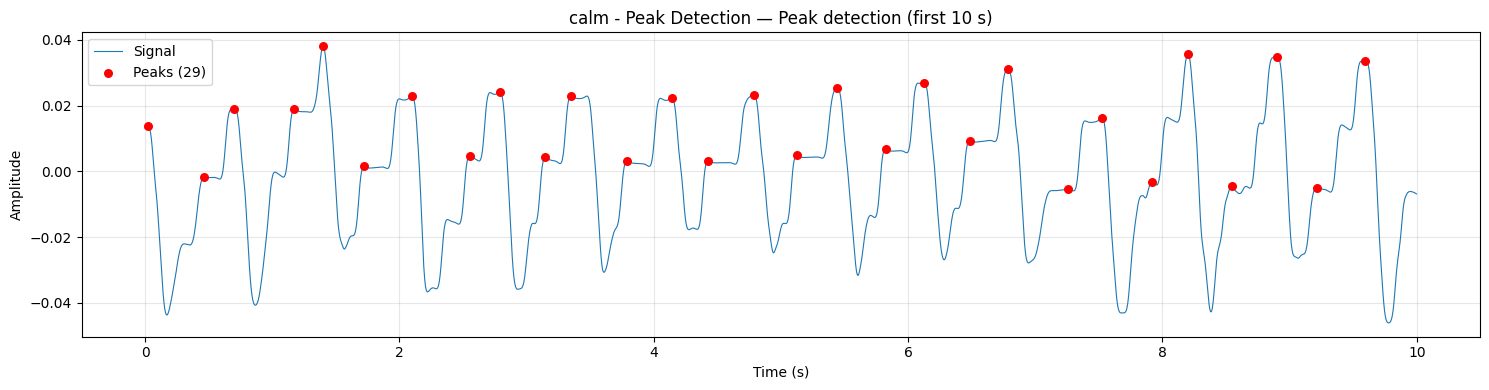

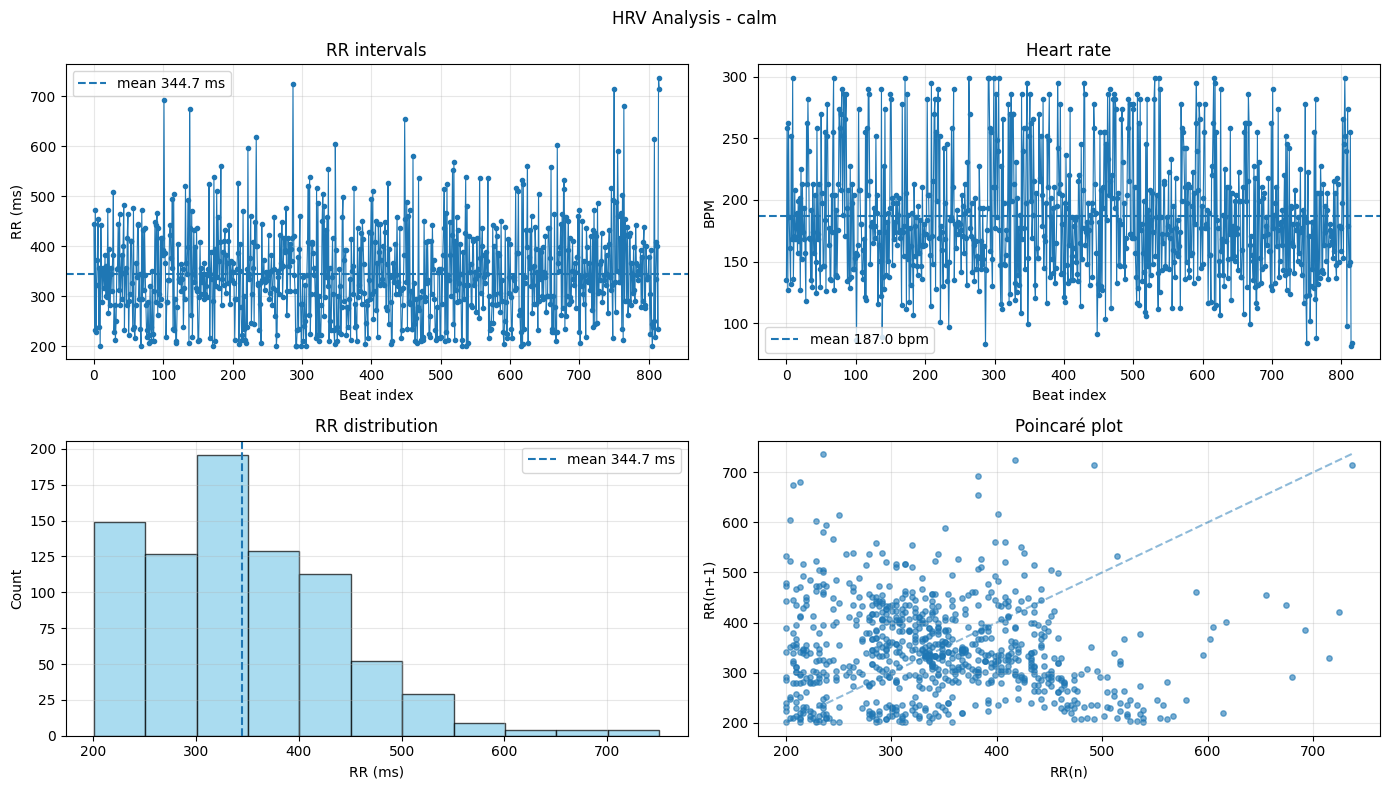

Анализ: walk
raw: 95783
cropped: 89403
after HP: 89403
after LP: 89403
Индекс напряжения: 0.00007
-0.12010024027140502 0.7896340559560823 0.03713339670909929
Обнаружено пиков: 868
Эффективных RR-интервалов: 855
Средняя ЧСС: 201.5 bpm


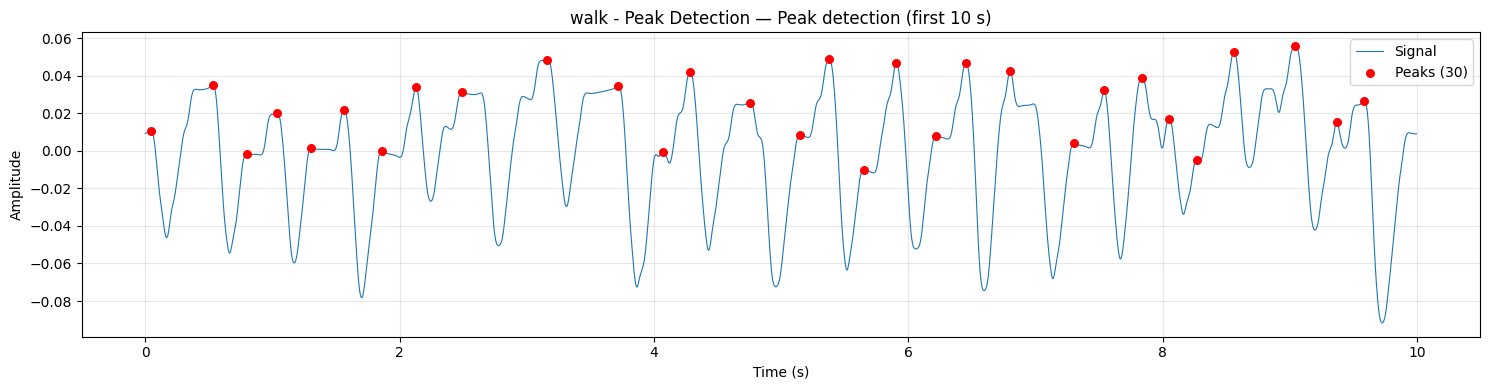

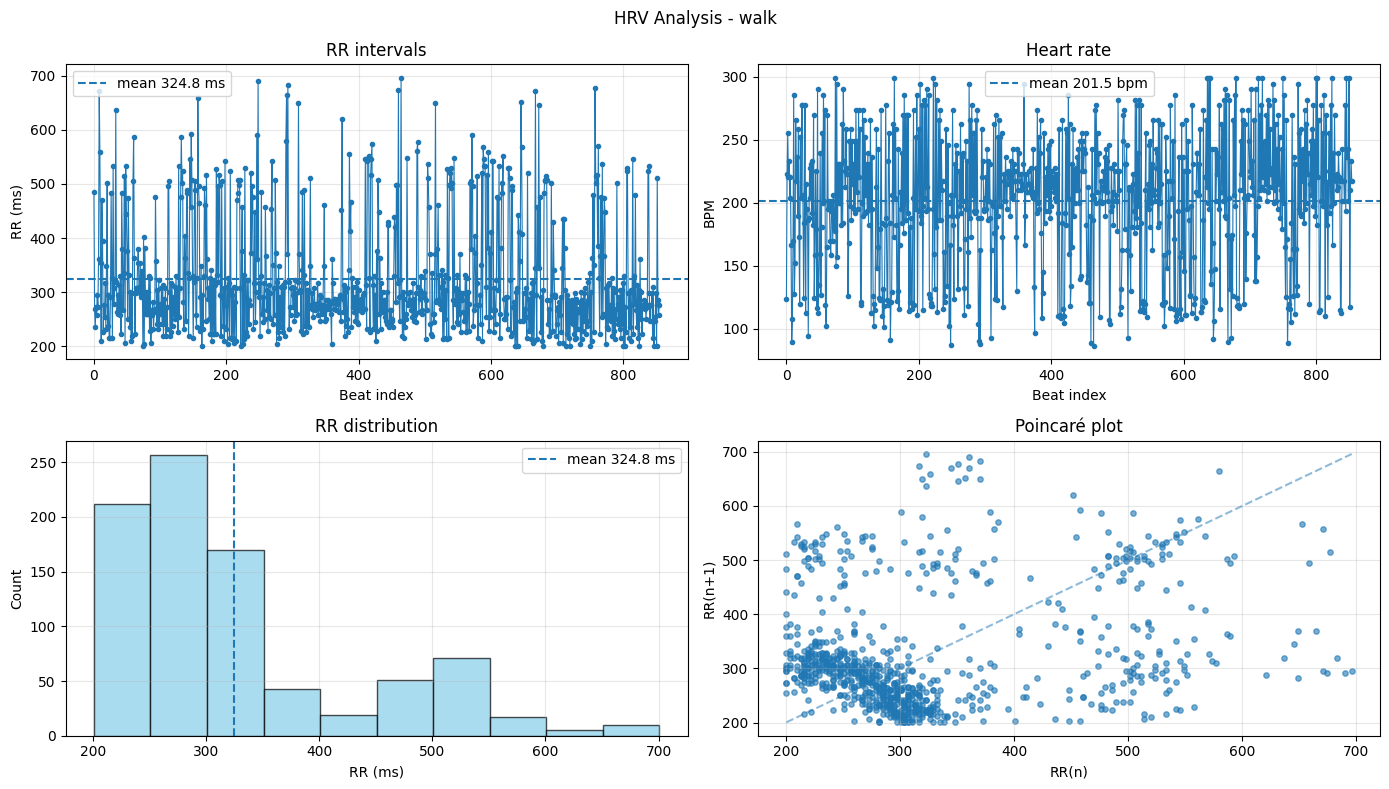

Анализ: run1
raw: 22043
cropped: 15663
after HP: 15663
after LP: 15663
Индекс напряжения: 0.00010
-0.18231045237641516 0.38340281906975665 0.057121155203699245
Обнаружено пиков: 133
Эффективных RR-интервалов: 131
Средняя ЧСС: 168.3 bpm


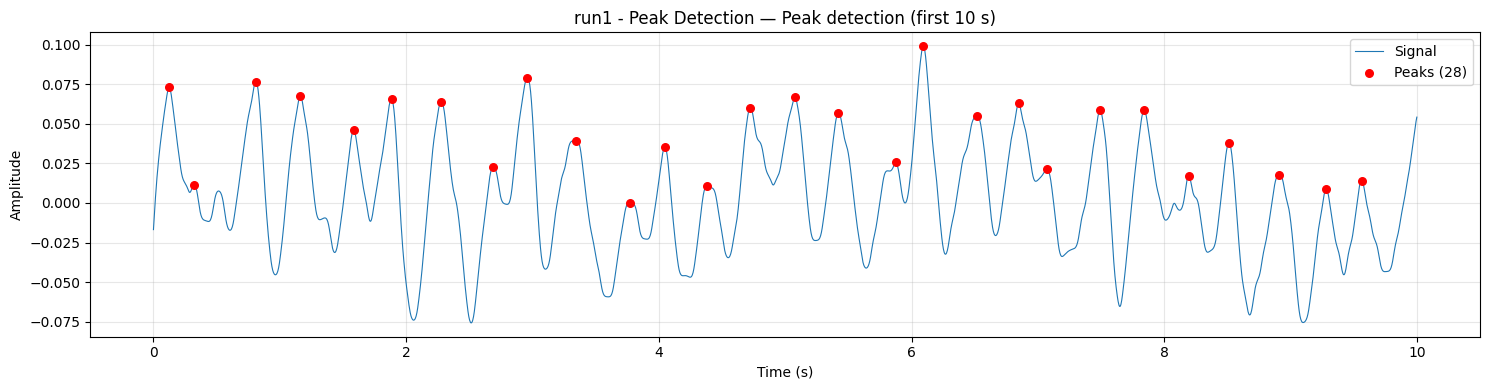

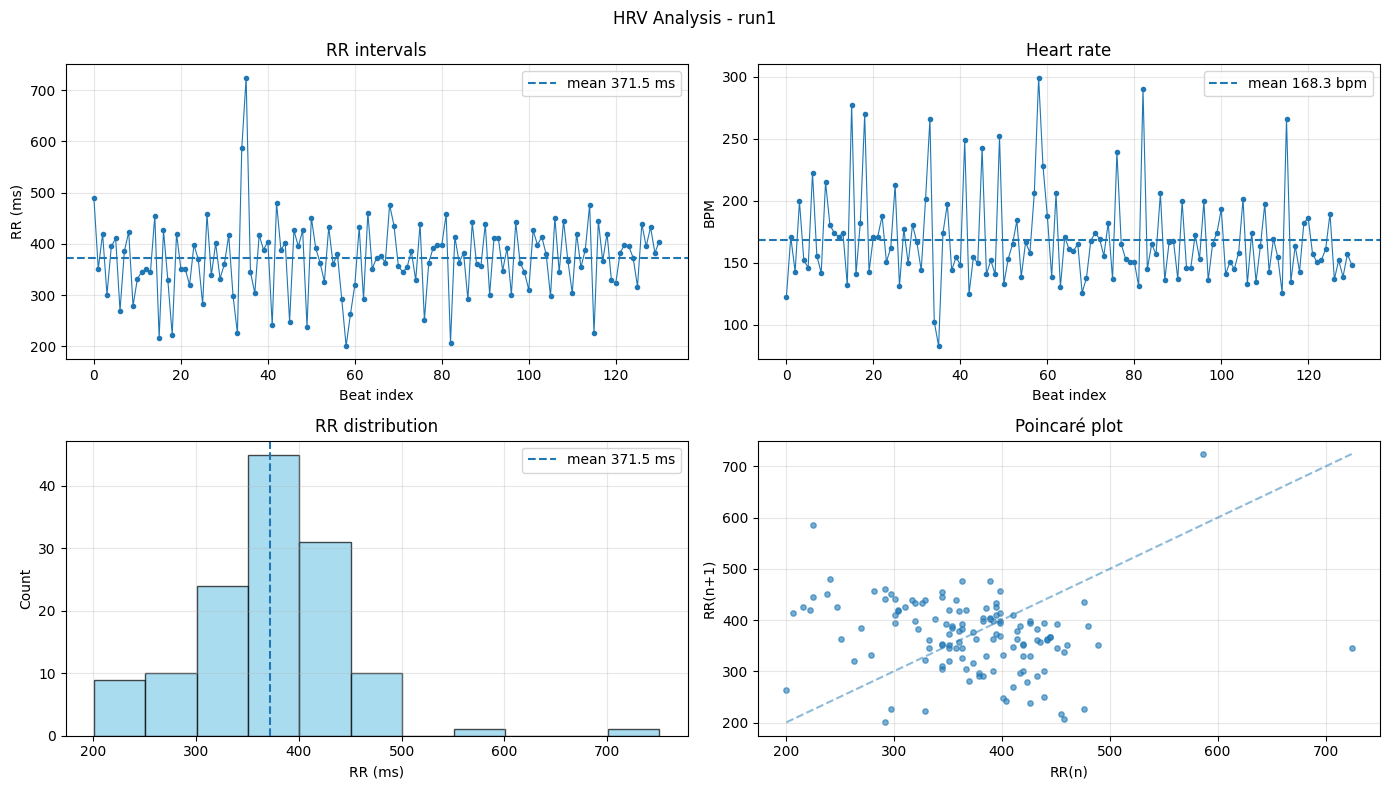

Анализ: after_run1
raw: 38650
cropped: 32270
after HP: 32270
after LP: 32270
Индекс напряжения: 0.00008
-0.1209349373886579 0.07194995614468538 0.02929011824342851
Обнаружено пиков: 338
Эффективных RR-интервалов: 335
Средняя ЧСС: 210.6 bpm


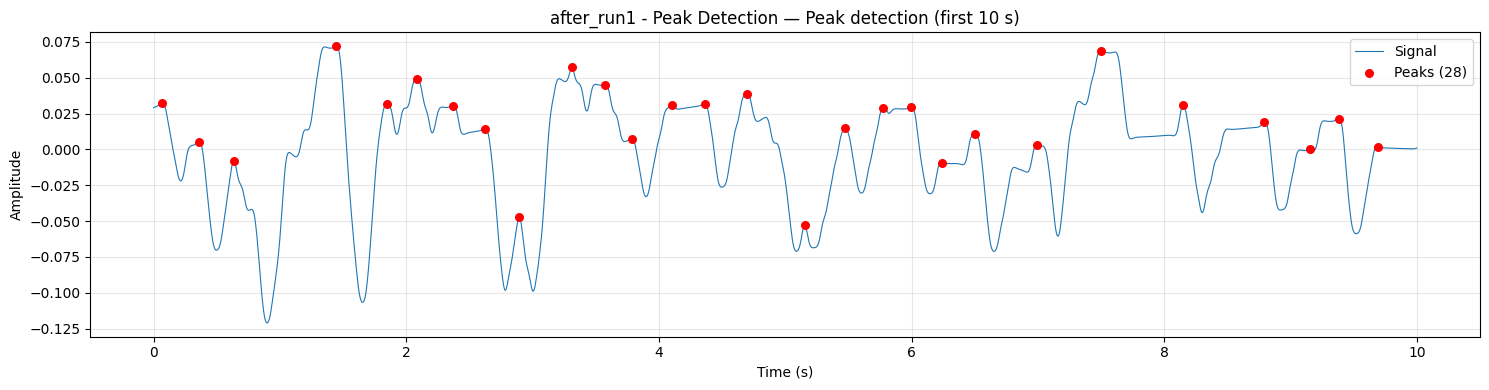

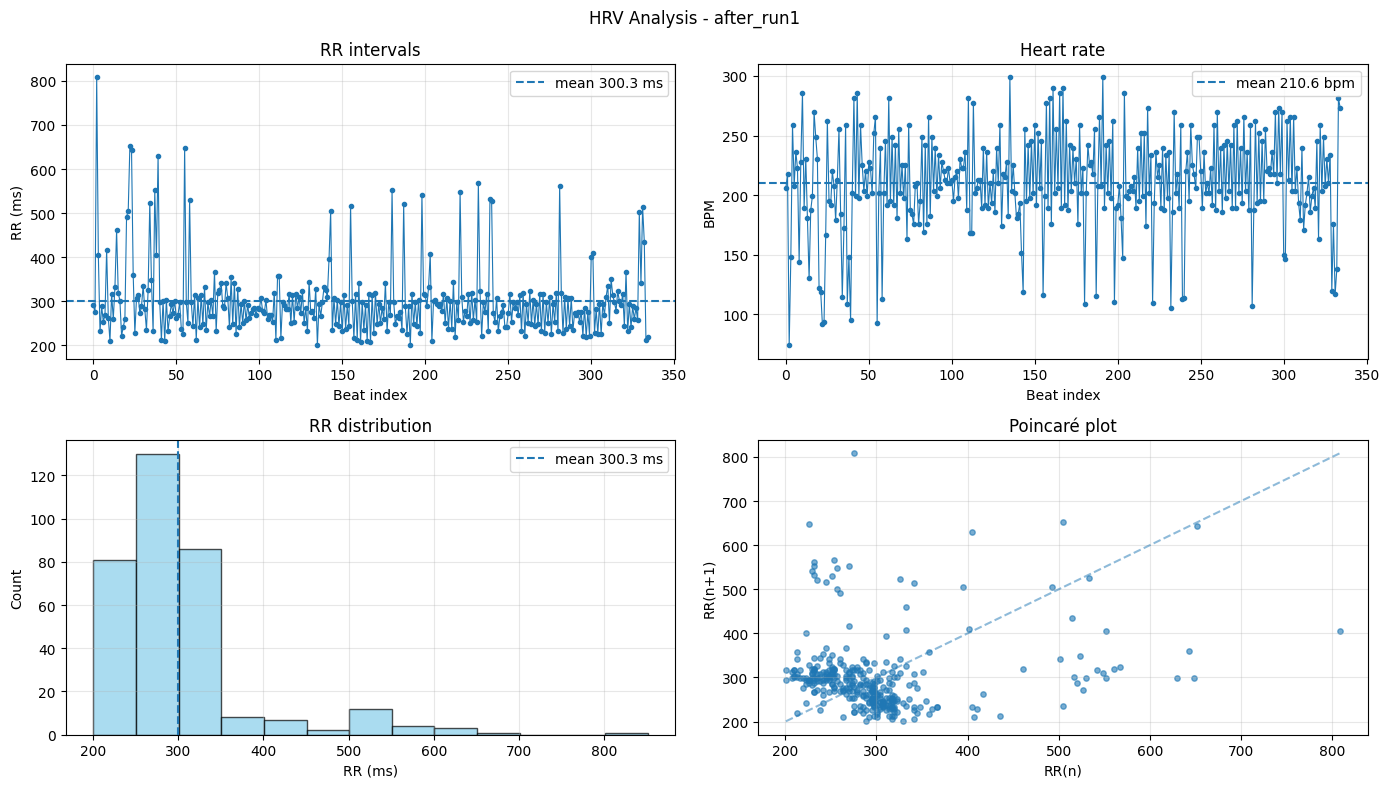

Анализ: run5
raw: 95978
cropped: 89598
after HP: 89598
after LP: 89598
Индекс напряжения: 0.00014
-0.2383484957571707 0.4093610150475074 0.05518124467141804
Обнаружено пиков: 738
Эффективных RR-интервалов: 729
Средняя ЧСС: 169.5 bpm


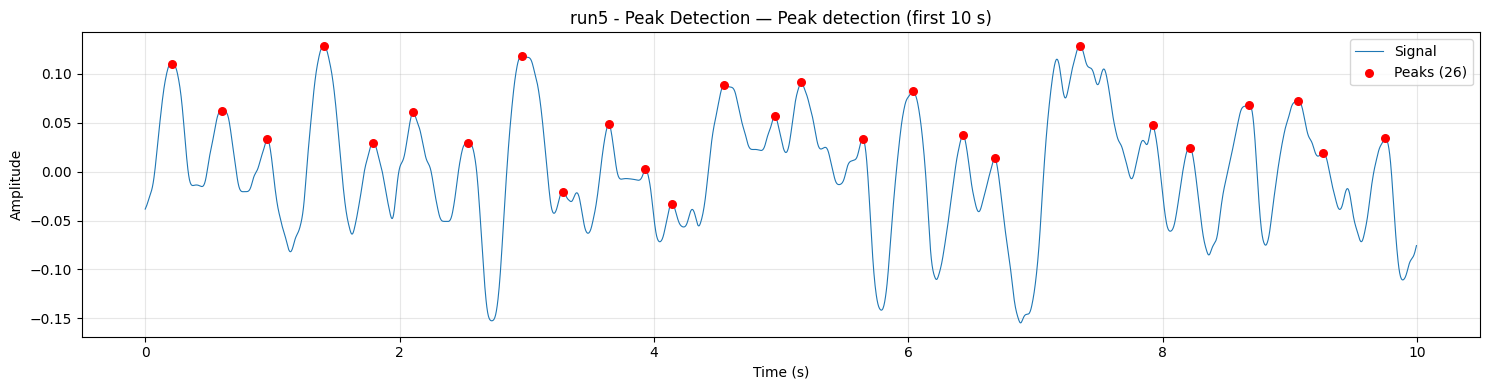

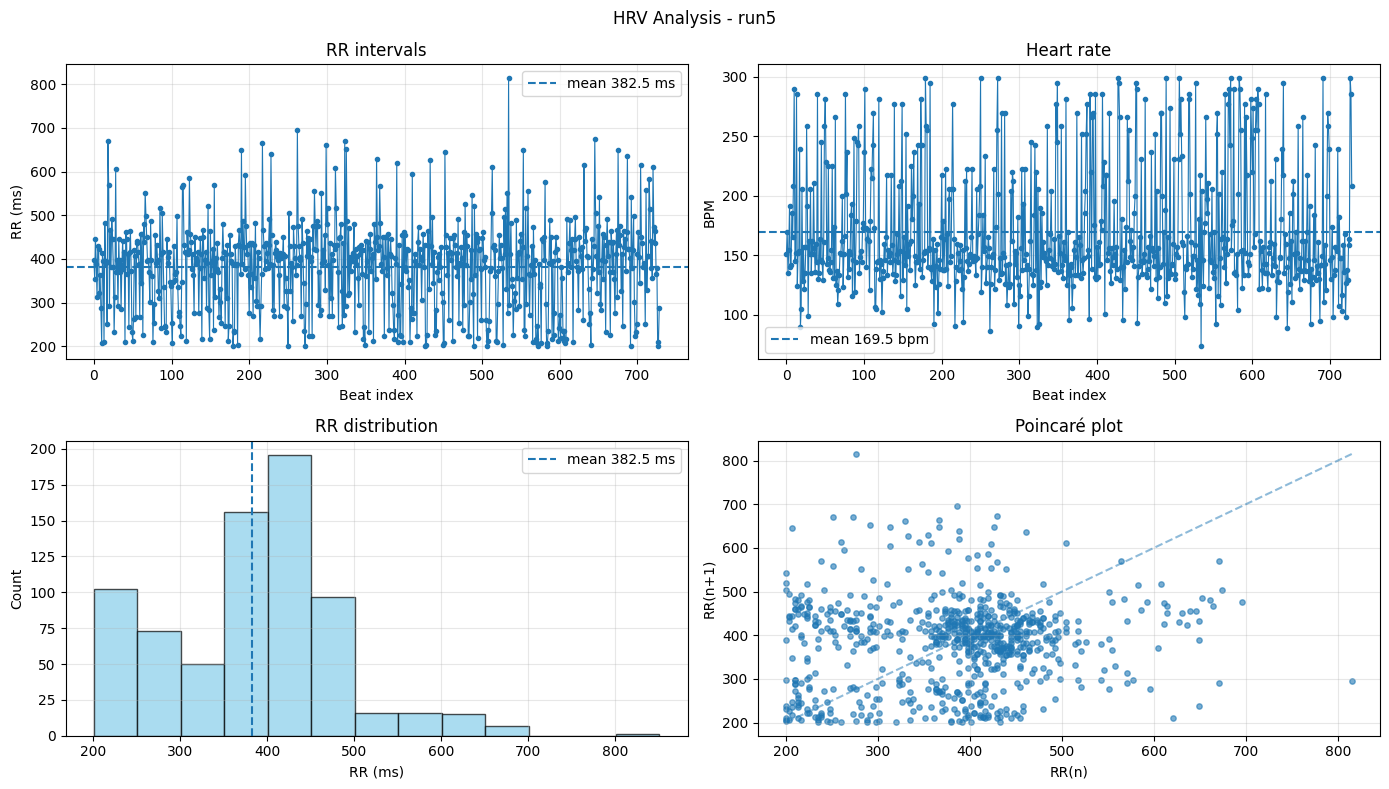

Анализ: after_run5
raw: 52635
cropped: 46255
after HP: 46255
after LP: 46255
Индекс напряжения: 0.00007
-0.0956585732280856 0.09015871210441591 0.022776210365529126
Обнаружено пиков: 442
Эффективных RR-интервалов: 434
Средняя ЧСС: 198.1 bpm


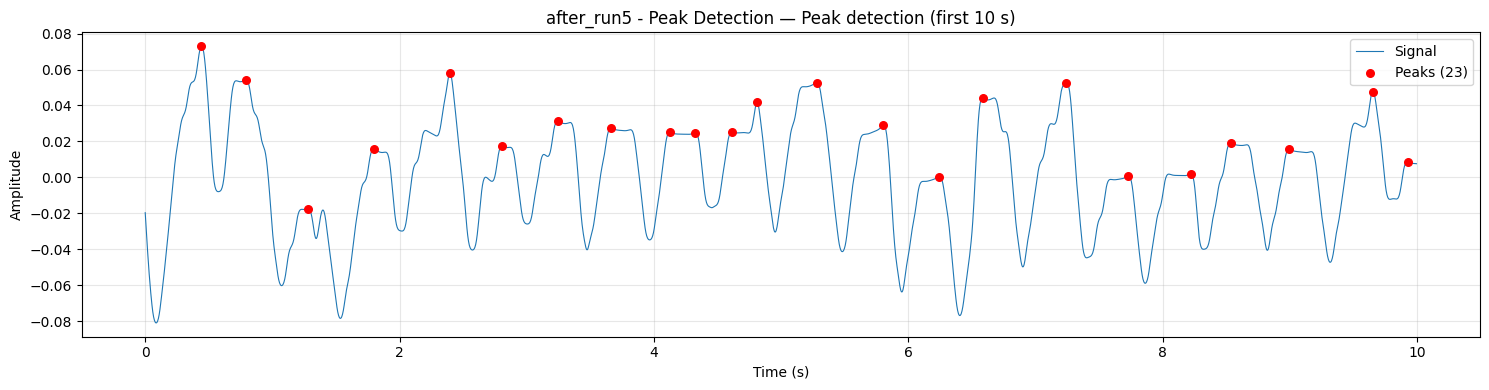

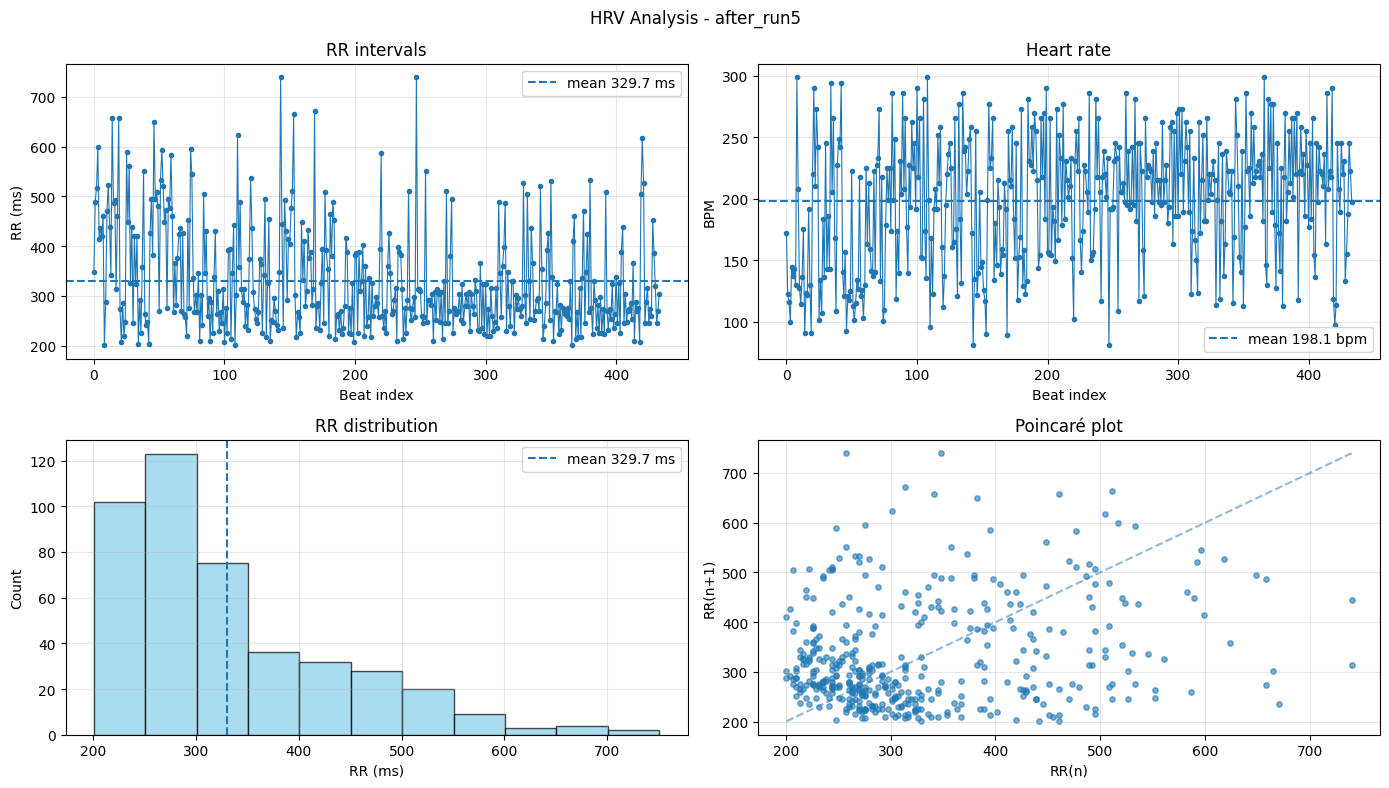

,Состояние,"ЧСС, уд/мин","SDNN, мс","RMSSD, мс","pNN50, %","Ср. RR, мс",N RR
0,calm,174.1,94.1,138.4,71.0,344.7,816
1,walk,184.7,107.5,134.9,69.3,324.8,855
2,run1,161.5,72.9,111.3,65.4,371.5,131
3,after_run1,199.8,83.3,112.1,62.3,300.3,335
4,run5,156.8,100.4,135.3,66.3,382.5,729
5,after_run5,182.0,106.0,133.3,67.4,329.7,434


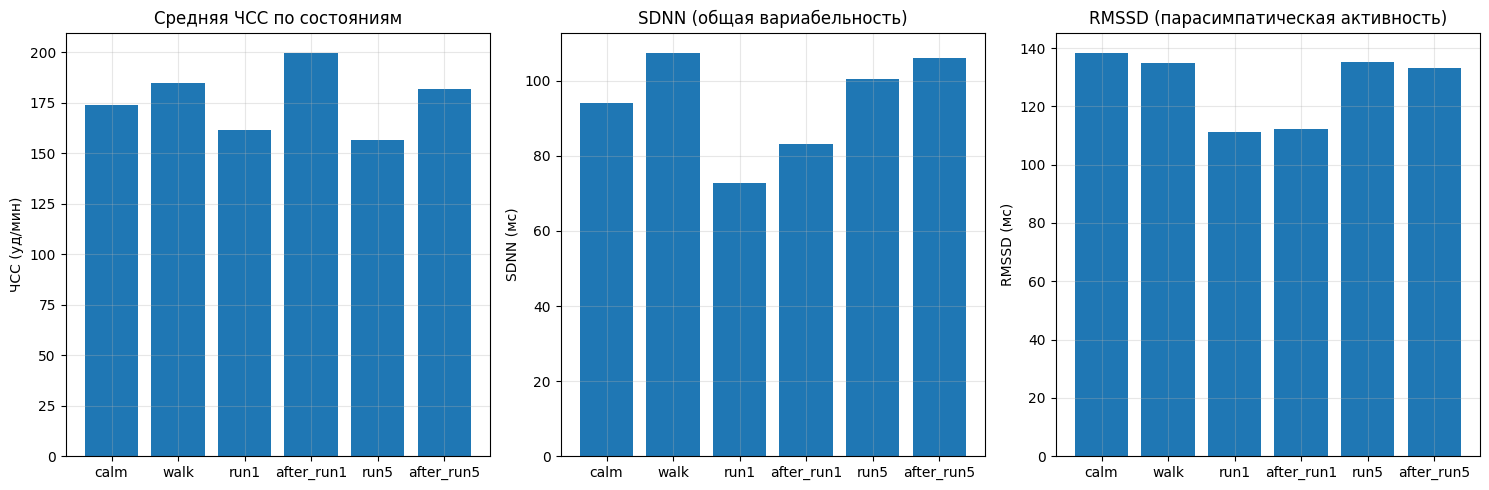

In [ ]:
import pandas as pd

results = {}

summary_data = []

final_signals = {
    "calm": signals['calm_FPG.dat'],
    "walk": signals['walk_FPG.dat'],
    "run1": signals['run1_FPG.dat'],
    "after_run1": signals['after_run1_FPG.dat'],
    "run5": signals['run5_FPG.dat'],
    "after_run5": signals['after_run5_FPG.dat']
}

for name, data in final_signals.items():
    print(f"Анализ: {name}")

    signal_cropped = crop_signal(
        data['signal'], fs,
        trim_start_sec=10,
        trim_end_sec=10
    )

    signal_hp = highpass_filter(
        signal_cropped, fs,
        cutoff_hz=0.2,
        filter_order=1
    )

    signal_lp = lowpass_filter(
        signal_hp, fs,
        cutoff_hz=12,
        filter_order=2
    )

    si = stress_index(rr_ms)

    print("raw:", len(data['signal']))
    print("cropped:", len(signal_cropped))
    print("after HP:", len(signal_hp))
    print("after LP:", len(signal_lp))
    print(f"Индекс напряжения: {si:.5f}")

    print(signal_lp.min(), signal_lp.max(), signal_lp.std())

    peaks, peak_times = detect_peaks(
        signal_lp, fs,
        min_distance_s=0.2,
        prominence_factor = 0.3 * np.std(signal)
    )

    print(f"Обнаружено пиков: {len(peaks)}")

    if len(peaks) < 10:
        print("Предупреждение: слишком мало пиков!")
        results[name] = None
        continue

    rr_ms, heart_rate = calculate_heart_rate(
        peak_times,
        min_rr_ms=200,
        max_rr_ms=1500
    )

    print(f"Эффективных RR-интервалов: {len(rr_ms)}")

    if len(heart_rate) > 0:
        print(f"Средняя ЧСС: {np.mean(heart_rate):.1f} bpm")
    else:
        print("ЧСС не удалось рассчитать")

    hrv_results = calculate_hrv_metrics(rr_ms)

    plot_peaks_first_10s(signal_lp, peaks, fs, title=f"{name} - Peak Detection")
    plot_hrv_analysis(rr_ms, heart_rate, title=f"HRV Analysis - {name}")

    results[name] = {
        "peaks": peaks,
        "peak_times": peak_times,
        "rr_ms": rr_ms,
        "heart_rate": heart_rate,
        "hrv": hrv_results,
        "signal_lp": signal_lp
    }

    if hrv_results:
        summary_data.append({
            "Состояние": name,
            "ЧСС, уд/мин": hrv_results["mean_hr_bpm"],
            "SDNN, мс": hrv_results["sdnn_ms"],
            "RMSSD, мс": hrv_results["rmssd_ms"],
            "pNN50, %": hrv_results["pnn50_percent"],
            "Ср. RR, мс": hrv_results["mean_rr_ms"],
            "N RR": hrv_results["n_intervals"]
        })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

states = summary_df["Состояние"].values

axes[0].bar(states, summary_df["ЧСС, уд/мин"])
axes[0].set_title("Средняя ЧСС по состояниям")
axes[0].set_ylabel("ЧСС (уд/мин)")
axes[0].grid(alpha=0.3)

axes[1].bar(states, summary_df["SDNN, мс"])
axes[1].set_title("SDNN (общая вариабельность)")
axes[1].set_ylabel("SDNN (мс)")
axes[1].grid(alpha=0.3)

axes[2].bar(states, summary_df["RMSSD, мс"])
axes[2].set_title("RMSSD (парасимпатическая активность)")
axes[2].set_ylabel("RMSSD (мс)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def plot_all_poincare(rr_dict):

    plt.figure(figsize=(10, 10))

    for name, rr in rr_dict.items():

        plt.scatter(
            rr[:-1],
            rr[1:],
            s=12,
            alpha=0.5,
            label=name
        )

    all_values = np.concatenate(list(rr_dict.values()))

    min_rr = np.min(all_values)
    max_rr = np.max(all_values)

    plt.plot(
        [min_rr, max_rr],
        [min_rr, max_rr],
        'k--',
        alpha=0.5
    )

    plt.title("Poincare Plots Comparison")

    plt.xlabel("RR(n) (ms)")
    plt.ylabel("RR(n+1) (ms)")

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.show()

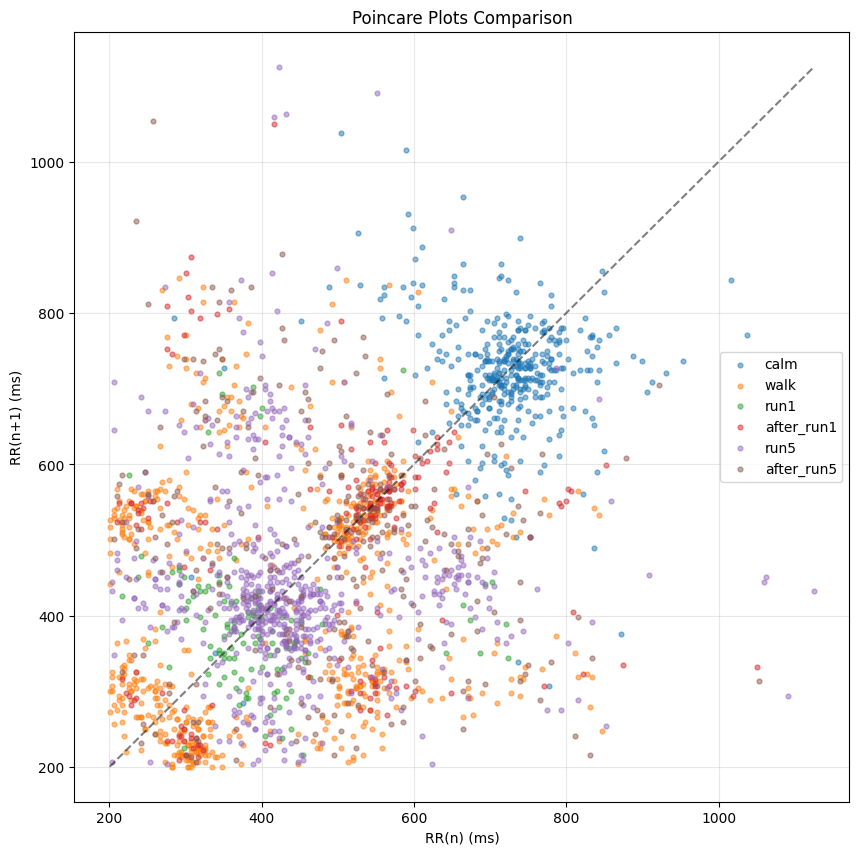

In [ ]:
rr_data = {
    "calm": results['calm']['rr_ms'],
    "walk": results['walk']['rr_ms'],
    "run1": results['run1']['rr_ms'],
    "after_run1": results['after_run1']['rr_ms'],
    "run5": results['run5']['rr_ms'],
    "after_run5": results['after_run5']['rr_ms']
}

plot_all_poincare(rr_data)

## Вывод

В состоянии покоя средняя ЧСС около 82.7 уд/мин, а показатели вариабельности (SDNN ≈ 79 мс, RMSSD ≈ 125 мс, pNN50 ≈ 58%) достаточно высокие. Это соответствует нормальному состоянию с выраженной вариабельностью сердечного ритма и преобладанием парасимпатической регуляции.

При ходьбе ожидаемо наблюдается рост ЧСС до 100 уд/мин. Одновременно снижается средняя RR и немного уменьшается вариабельность (RMSSD и pNN50), что отражает усиление симпатической активности и стабилизацию ритма под нагрузкой.

Сегмент run1 выглядит аномальным по сравнению с физиологической картиной: ЧСС 86.3 уд/мин ниже, чем при ходьбе, а N RR очень мал (28). Это указывает на недостаточную надёжность детекции пиков или проблемы качества сигнала/обработки именно в этом участке. Поэтому результаты для run1 нельзя интерпретировать как достоверные.

После бега ЧСС повышается до 101.9 уд/мин, при этом RMSSD и pNN50 снижаются относительно покоя, что соответствует состоянию восстановления после нагрузки с ещё сохраняющимся симпатическим влиянием.

В длительном беге наблюдается выраженное увеличение вариабельности (RMSSD ~160 мс, pNN50 ~72%), что выглядит нетипично для интенсивной нагрузки. Обычно при беге вариабельность снижается. Это может говорить о влиянии артефактов движения или ошибках в детекции RR-интервалов.

После длительного бега ЧСС остаётся повышенной (94.8 уд/мин), а показатели вариабельности высокие (RMSSD ~165 мс, pNN50 ~70%), что ближе к восстановительному состоянию, но также может содержать шумовые искажения.